In [5]:
# importing required python libraries for Data Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

# Connect to the MySQL database using this details
db = mysql.connector.connect(host = "localhost",
                           username = "root",
                           password = "MySQL@9635",
                           database = "target")

# Bring the cursor to the database
cur = db.cursor()

                           

# 1. List all Unique cities where customers are located.

In [2]:
# SQL query to find all unique cities where customers are located
query = """SELECT distinct customer_city FROM customers;"""

# To make the cursor on the database execute the above SQL query
cur.execute(query)

# To fetch all data extracted by the above SQL query
data = cur.fetchall()

data


[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# 2. Count the number of orders placed in 2017.

In [9]:
query = """SELECT count(order_id) FROM orders WHERE extract(year from order_purchase_timestamp) = 2017 group by extract(year from order_purchase_timestamp);"""
        


# To make the cursor on the database execute the above SQL query
cur.execute(query)

# To fetch all data extracted by the above SQL query
data = cur.fetchall()

"Total orders placed in 2017 are", data[0][0]

('Total orders placed in 2017 are', 45101)

# 3. Find the total sales per category.

In [8]:
query = """ select products.product_category category,
round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id=order_items.product_id
join payments
on payments.order_id=order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()

df= pd.DataFrame(data, columns= ["category", "sales"])

df



,category,sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


# 4. Calculate the percentage of orders that were paid in installments.

In [16]:
query = """ select (sum(case when payment_installments>=1 then 1 else 0 end))/count(*)*100 from payments"""

cur.execute(query)

data = cur.fetchall()

data



[(Decimal('99.9981'),)]

# 5. Count the number of customers from each state. 

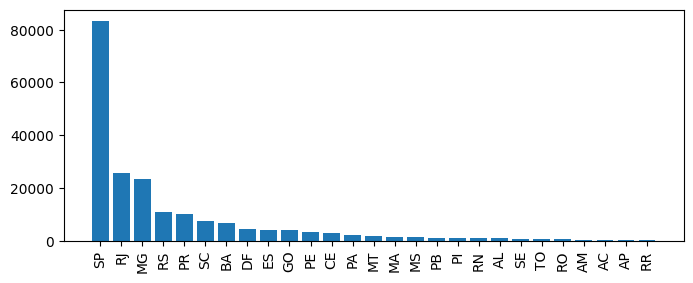

In [20]:
query = """ SELECT customer_state,count(customer_id)
from customers 
group by customer_state;
"""

cur.execute(query)

data = cur.fetchall()

df= pd.DataFrame(data, columns=["State", "No. Of Customers"])
df =df.sort_values(by = "No. Of Customers", ascending= False)


plt.figure(figsize = (8,3))
plt.bar(df["State"], df["No. Of Customers"])
plt.xticks(rotation = 90)
plt.show()

# 6. Calculate the number of orders per month in 2018.

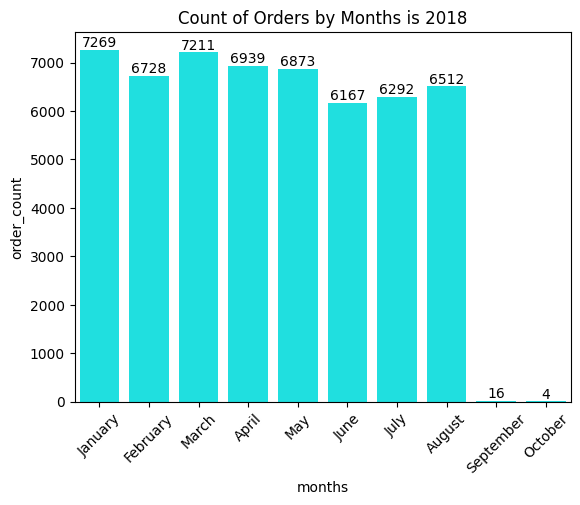

In [15]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February","March","April","May","June","July","August","September","October"]

ax = sns.barplot(x = df["months"],y =  df["order_count"], data = df, order = o, color = "cyan")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months is 2018")

plt.show()

# 7. Find the average number of products per order, grouped by customer city. Show the top 10 results


In [24]:
query = """with count_per_order as 
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["customer city", "average products per order"])

print(df.head(10))


        customer city average products per order
0      padre carvalho                       7.00
1         celso ramos                       6.50
2               datas                       6.00
3       candido godoi                       6.00
4      matias olimpio                       5.00
5          cidelandia                       4.00
6          curralinho                       4.00
7             picarra                       4.00
8  morro de sao paulo                       4.00
9     teixeira soares                       4.00


# 8.  Calculate the percentage of total revenue contributed by each product category. Show top 5 results.

In [25]:
query = """select upper(products.product_category) category, 
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
from products join order_items 
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc"""


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category", "percentage distribution"])
df.head()

,Category,percentage distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93


# 9.  Identify the correlation between product price and the number of times a product has been purchased.

In [28]:
import numpy as np
query = """select products.product_category, 
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category", "order_count","price"])

arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef([arr1,arr2])
print("the correlation is", a[0][-1])

the correlation is -0.10631514167157562


In [29]:
# we can conclude that there is no relation between product price and the number of times a product has been purchased.As the correlation value is near to zero (approx 0).

# 10. Calculate the total revenue generated by each seller, and rank them by revenue. And mention the top 10 sellers according to their ranks.


In [35]:
query = """WITH seller_sales AS (
    SELECT seller_id, ROUND(SUM(price), 2) AS sales
    FROM order_items
    GROUP BY seller_id
)
SELECT seller_id, sales,
       DENSE_RANK() OVER (ORDER BY sales DESC) AS sellers_rank
FROM seller_sales;"""
cur.execute(query)
data= cur.fetchall()
df = pd.DataFrame(data, columns=['seller_id','sales_revenue','rank'])
df.head(10)

,seller_id,sales_revenue,rank
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1
1,53243585a1d6dc2643021fd1853d8905,222776.05,2
2,4a3ca9315b744ce9f8e9374361493884,200472.92,3
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,4
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,5
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,6
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,7
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,8
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,9
9,955fee9216a65b617aa5c0531780ce60,135171.70,10


# 11.  Calculate the moving average of order values for each customer over their order history.

In [3]:
query = """select customer_id, order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp, 
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# 12. Calculate the cumulative sales per month for each year.

In [5]:

query = """select years, months , payment, sum(payment)
over(order by years, months) cumulative_sales from 
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years, months order by years, months) as a
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# 13. Calculate the year-over-year growth rate of total sales.

In [7]:
query = """with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment - lag(payment, 1) over(order by years))/
lag(payment, 1) over(order by years)) * 100 from a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "year_over_year_growth_percent"])
df


,years,year_over_year_growth_percent
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# 14. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [8]:
query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id) 

select 100 * (count( distinct a.customer_id)/ count(distinct b.customer_id)) 
from a left join b 
on a.customer_id = b.customer_id ;"""

cur.execute(query)
data = cur.fetchall()

data

[(None,)]

In [9]:
# Since there are no customers who purchased within 6 months of their first purchase, the value is null

# 15. Identify the top 3 customers who spent the most money in each year.

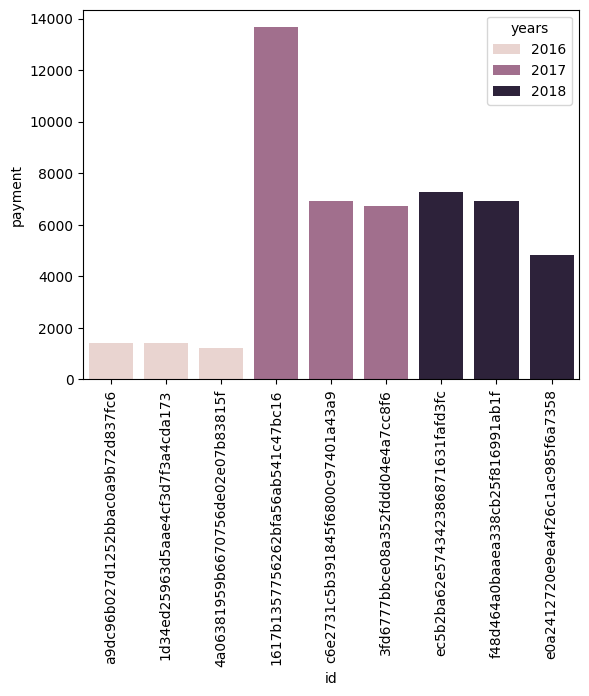

In [10]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments 
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 ;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","id","payment","rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()